# Binder Cumulant Analysis of Overlapping Gene Systems

## Motivation

The **Binder cumulant** $U = 1 - \frac{\langle m^4 \rangle}{3 \langle m^2 \rangle^2}$ is a dimensionless ratio that distinguishes phase transition types:

| Regime | $U$ value | Interpretation |
|---|---|---|
| Ordered phase | $U \to 2/3$ | Narrow distribution around non-zero $\langle m \rangle$ |
| Disordered phase | $U \to 0$ | Gaussian fluctuations around $\langle m \rangle = 0$ |
| First-order transition | $U < 0$ | Bimodal distribution (phase coexistence) |

At a **continuous transition**, $U(T)$ curves at different system sizes $L$ cross at a **universal point** $T_c$ — enabling size-independent determination of the critical temperature. For our overlapping genes system, the **overlap length** plays the role of $L$.

The criticality analysis heatmaps revealed a striking **horizontal band structure** in $U(T_1, T_2)$: a blue band ($U \approx 0$ or negative) at intermediate $T_2$, flanked by red bands ($U \to 2/3$). This suggests the critical behavior is primarily controlled by $T_2$ (the constrained protein). This notebook provides systematic 1D cuts through this landscape, crossing detection, and finite-size scaling analysis.

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.interpolate import interp1d
from scipy.optimize import brentq, minimize_scalar
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# ─── Load checkpoint ───
with open('checkpoints/systematic_results.pkl', 'rb') as f:
    all_results = pickle.load(f)

print(f"Loaded {len(all_results)} configurations")
for key, res in sorted(all_results.items()):
    print(f"  {key}: {res['PF_A']} x {res['PF_B']}, overlap={res['overlap']} nt")


# ─── Helper functions (from criticality_analysis.ipynb) ───

def compute_order_parameters(Z1, Z2):
    """Compute multiple candidate order parameters from z-score samples.

    Returns: (asymmetry, combined, euclidean) arrays
    """
    abs_sum = np.abs(Z1) + np.abs(Z2)
    safe_sum = np.where(abs_sum == 0, 1.0, abs_sum)
    asymmetry = (np.abs(Z1) - np.abs(Z2)) / safe_sum
    combined = np.abs(Z1) + np.abs(Z2)
    euclidean = np.sqrt(Z1**2 + Z2**2)
    return asymmetry, combined, euclidean


def binder_cumulant(m_samples):
    """U = 1 - <m^4> / (3 <m^2>^2)"""
    m2 = np.mean(m_samples**2)
    m4 = np.mean(m_samples**4)
    if m2 == 0:
        return 0.0
    return 1.0 - m4 / (3.0 * m2**2)


def block_bootstrap_error(samples, fn, n_blocks=20):
    """Block bootstrap error estimate for a scalar statistic."""
    n = len(samples)
    block_size = max(1, n // n_blocks)
    stats = [fn(samples[i*block_size:(i+1)*block_size])
             for i in range(n_blocks) if (i+1)*block_size <= n]
    return np.std(stats) if len(stats) > 1 else 0.0


# ─── New analysis helpers ───

def extract_1d_cut(U_grid, T1_arr, T2_arr, direction, fixed_val):
    """Extract U along a 1D slice of the 2D grid.

    Parameters
    ----------
    U_grid : (nT2, nT1) array
    T1_arr, T2_arr : 1D temperature arrays
    direction : 'horizontal' (vary T2, fix T1) or 'vertical' (vary T1, fix T2)
    fixed_val : temperature value to fix (snaps to nearest grid point)

    Returns
    -------
    T_vary : 1D array of varying temperature
    U_slice : 1D array of Binder cumulant values
    fixed_actual : actual grid temperature used
    """
    if direction == 'horizontal':
        idx = np.argmin(np.abs(T1_arr - fixed_val))
        return T2_arr, U_grid[:, idx], T1_arr[idx]
    else:  # vertical
        idx = np.argmin(np.abs(T2_arr - fixed_val))
        return T1_arr, U_grid[idx, :], T2_arr[idx]


def find_crossing(T_vals, U_curve1, U_curve2):
    """Find crossing point(s) of two U(T) curves via interpolation + root-finding.

    Returns list of (T_cross, U_cross) tuples.
    """
    # Common domain
    T_lo = max(T_vals[0], T_vals[0])
    T_hi = min(T_vals[-1], T_vals[-1])
    if T_lo >= T_hi:
        return []

    T_common = np.linspace(T_lo, T_hi, 500)

    try:
        f1 = interp1d(T_vals, U_curve1, kind='cubic', bounds_error=False,
                      fill_value='extrapolate')
        f2 = interp1d(T_vals, U_curve2, kind='cubic', bounds_error=False,
                      fill_value='extrapolate')
    except ValueError:
        return []

    delta = f1(T_common) - f2(T_common)
    crossings = []

    for k in range(len(delta) - 1):
        if delta[k] * delta[k+1] < 0:
            try:
                T_c = brentq(lambda t: f1(t) - f2(t),
                             T_common[k], T_common[k+1])
                crossings.append((T_c, float(f1(T_c))))
            except (ValueError, RuntimeError):
                pass

    return crossings


# ─── Organize data by pair ───
# Group configs: pairs dict maps pair_name -> {overlap: config}
pairs = {}
for key, res in all_results.items():
    pair_name = f"{res['PF_A']} x {res['PF_B']}"
    if pair_name not in pairs:
        pairs[pair_name] = {}
    pairs[pair_name][res['overlap']] = res

pair_names = sorted(pairs.keys())
print(f"\n{len(pair_names)} pairs:")
for pn in pair_names:
    overlaps = sorted(pairs[pn].keys())
    print(f"  {pn}: overlaps = {overlaps}")

# ─── Style ───
sns.set_context('notebook', font_scale=1.0)
PAIR_COLORS = ['#1f77b4', '#d62728', '#2ca02c', '#9467bd']
OVERLAP_STYLES = ['-', '--', ':']
OVERLAP_MARKERS = ['o', 's', 'D']

Loaded 12 configurations
  PF00004_PF00041_18: PF00004 x PF00041, overlap=18 nt
  PF00004_PF00041_45: PF00004 x PF00041, overlap=45 nt
  PF00004_PF00041_90: PF00004 x PF00041, overlap=90 nt
  PF00076_PF00512_18: PF00076 x PF00512, overlap=18 nt
  PF00076_PF00512_45: PF00076 x PF00512, overlap=45 nt
  PF00076_PF00512_90: PF00076 x PF00512, overlap=90 nt
  PF00096_PF00004_18: PF00096 x PF00004, overlap=18 nt
  PF00096_PF00004_30: PF00096 x PF00004, overlap=30 nt
  PF00096_PF00004_63: PF00096 x PF00004, overlap=63 nt
  PF00397_PF00072_18: PF00397 x PF00072, overlap=18 nt
  PF00397_PF00072_39: PF00397 x PF00072, overlap=39 nt
  PF00397_PF00072_78: PF00397 x PF00072, overlap=78 nt

4 pairs:
  PF00004 x PF00041: overlaps = [18, 45, 90]
  PF00076 x PF00512: overlaps = [18, 45, 90]
  PF00096 x PF00004: overlaps = [18, 30, 63]
  PF00397 x PF00072: overlaps = [18, 39, 78]


C:\Users\orson\AppData\Local\Temp\ipykernel_40268\2305409539.py:50: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1.0])


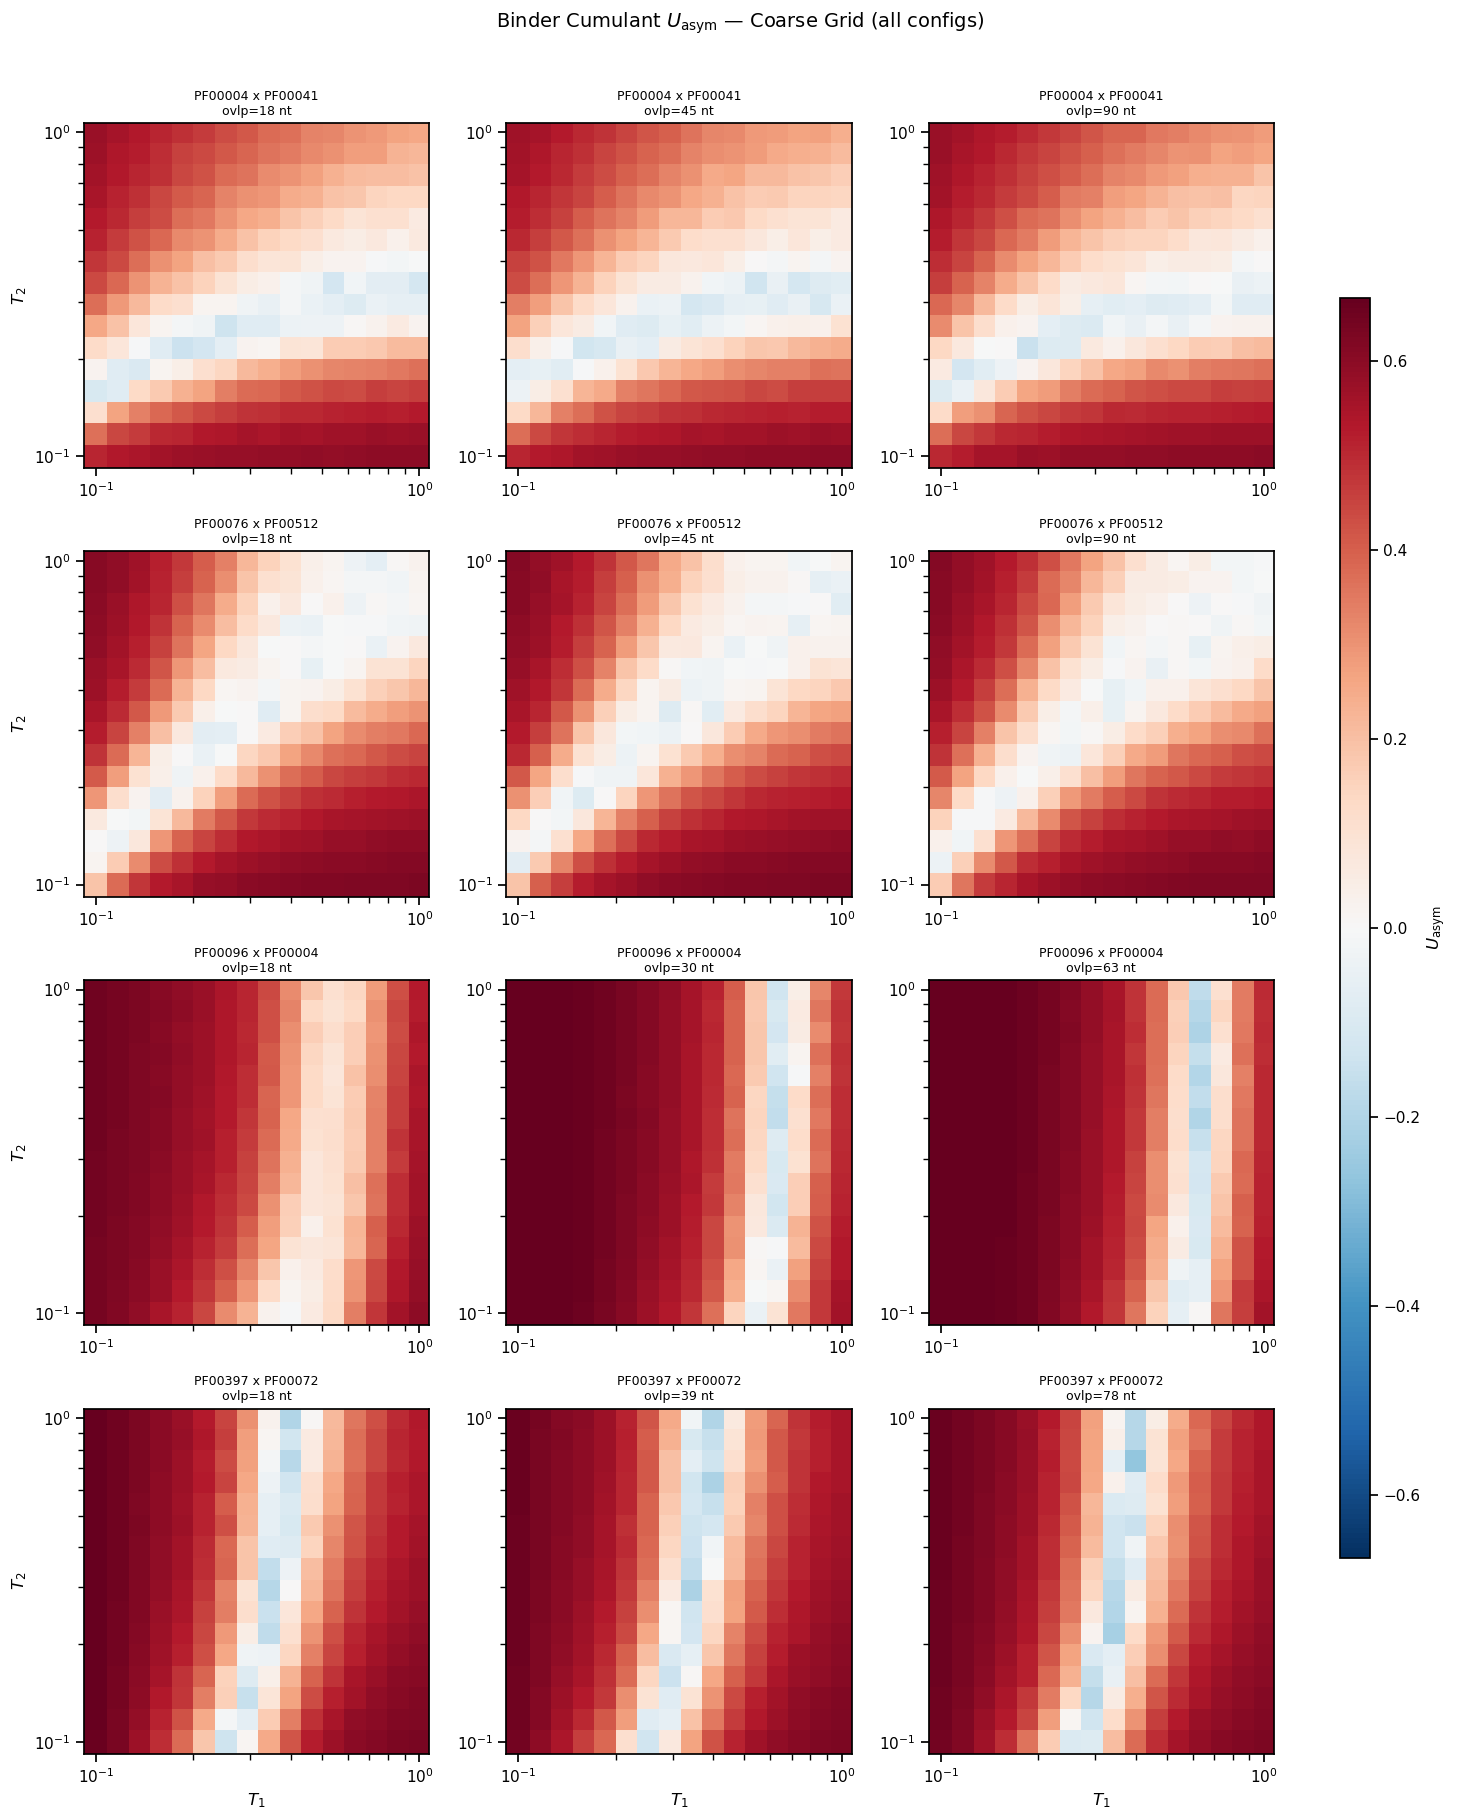

In [2]:
# ─── Cell 2: U_asym heatmap gallery (all 12 configs) ───
n_pairs = len(pair_names)
max_overlaps = max(len(pairs[pn]) for pn in pair_names)

fig, axes = plt.subplots(n_pairs, max_overlaps, figsize=(5 * max_overlaps, 4.5 * n_pairs),
                          squeeze=False)

# Compute global color limits for consistent colorbar
vmin, vmax = 1.0, -1.0
for pn in pair_names:
    for ovlp, res in pairs[pn].items():
        U = res['coarse']['obs']['U_asym']
        vmin = min(vmin, np.nanmin(U))
        vmax = max(vmax, np.nanmax(U))

# Symmetric limits centered at 0
vlim = max(abs(vmin), abs(vmax))

for row, pn in enumerate(pair_names):
    overlaps = sorted(pairs[pn].keys())
    for col in range(max_overlaps):
        ax = axes[row, col]
        if col < len(overlaps):
            ovlp = overlaps[col]
            res = pairs[pn][ovlp]
            T1 = res['coarse']['T1']
            T2 = res['coarse']['T2']
            U = res['coarse']['obs']['U_asym']

            im = ax.pcolormesh(T1, T2, U, cmap='RdBu_r',
                               vmin=-vlim, vmax=vlim, shading='nearest')
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_title(f"{pn}\novlp={ovlp} nt", fontsize=9)
            ax.set_aspect('equal')
        else:
            ax.set_visible(False)

        if col == 0:
            ax.set_ylabel('$T_2$')
        if row == n_pairs - 1:
            ax.set_xlabel('$T_1$')

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='$U_{\\mathrm{asym}}$')

fig.suptitle('Binder Cumulant $U_{\\mathrm{asym}}$ — Coarse Grid (all configs)',
             fontsize=14, y=1.01)
plt.tight_layout(rect=[0, 0, 0.88, 1.0])
plt.show()

C:\Users\orson\AppData\Local\Temp\ipykernel_40268\241409656.py:45: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.88, 1.0])


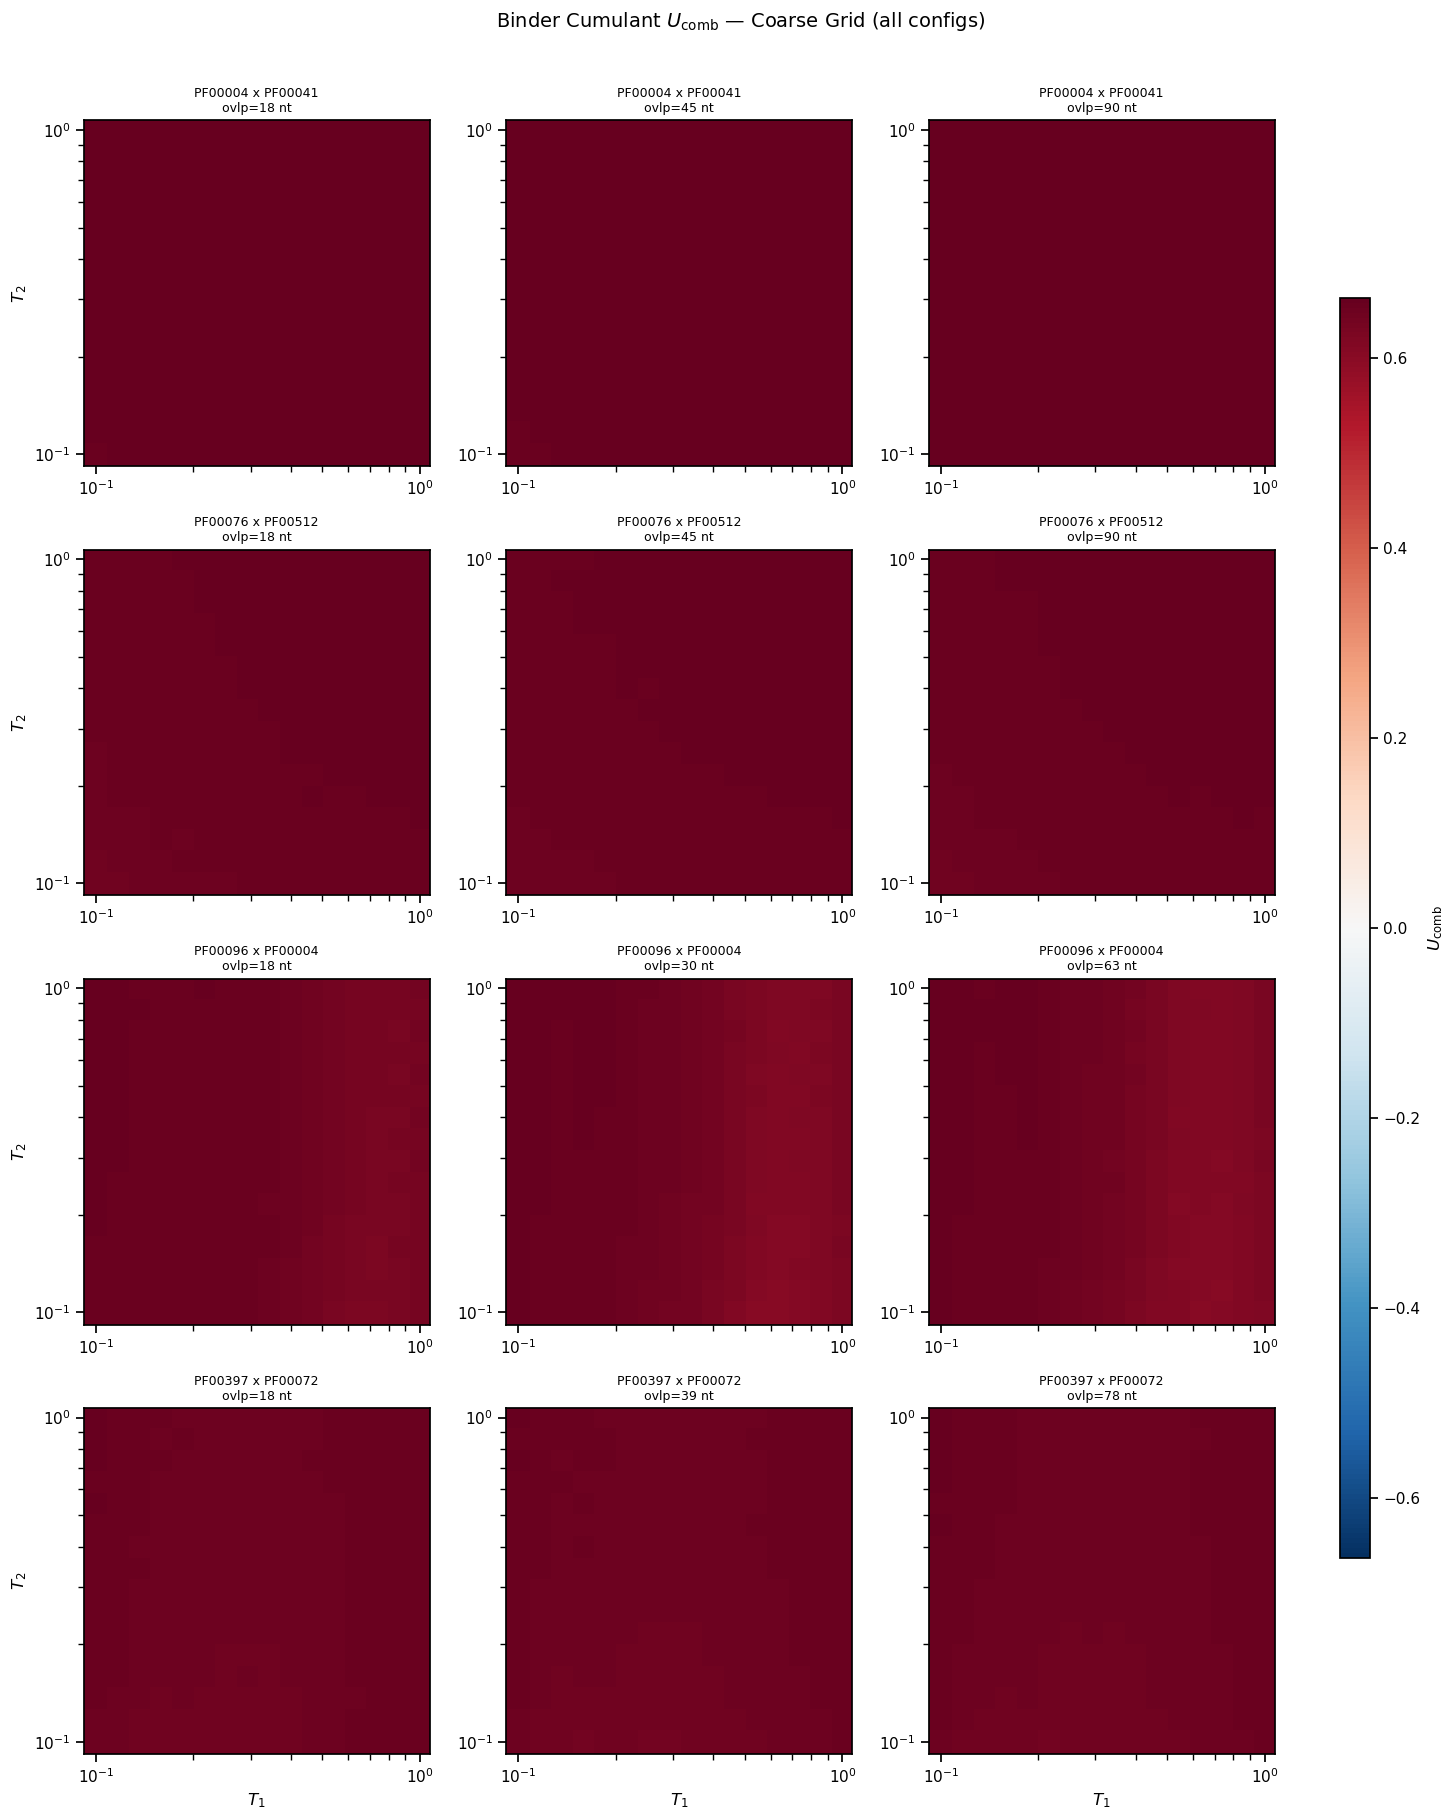

In [3]:
# ─── Cell 3: U_comb heatmap gallery (all 12 configs) ───
fig, axes = plt.subplots(n_pairs, max_overlaps, figsize=(5 * max_overlaps, 4.5 * n_pairs),
                          squeeze=False)

vmin_c, vmax_c = 1.0, -1.0
for pn in pair_names:
    for ovlp, res in pairs[pn].items():
        U = res['coarse']['obs']['U_comb']
        vmin_c = min(vmin_c, np.nanmin(U))
        vmax_c = max(vmax_c, np.nanmax(U))

vlim_c = max(abs(vmin_c), abs(vmax_c))

for row, pn in enumerate(pair_names):
    overlaps = sorted(pairs[pn].keys())
    for col in range(max_overlaps):
        ax = axes[row, col]
        if col < len(overlaps):
            ovlp = overlaps[col]
            res = pairs[pn][ovlp]
            T1 = res['coarse']['T1']
            T2 = res['coarse']['T2']
            U = res['coarse']['obs']['U_comb']

            im = ax.pcolormesh(T1, T2, U, cmap='RdBu_r',
                               vmin=-vlim_c, vmax=vlim_c, shading='nearest')
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_title(f"{pn}\novlp={ovlp} nt", fontsize=9)
            ax.set_aspect('equal')
        else:
            ax.set_visible(False)

        if col == 0:
            ax.set_ylabel('$T_2$')
        if row == n_pairs - 1:
            ax.set_xlabel('$T_1$')

fig.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax, label='$U_{\\mathrm{comb}}$')

fig.suptitle('Binder Cumulant $U_{\\mathrm{comb}}$ — Coarse Grid (all configs)',
             fontsize=14, y=1.01)
plt.tight_layout(rect=[0, 0, 0.88, 1.0])
plt.show()

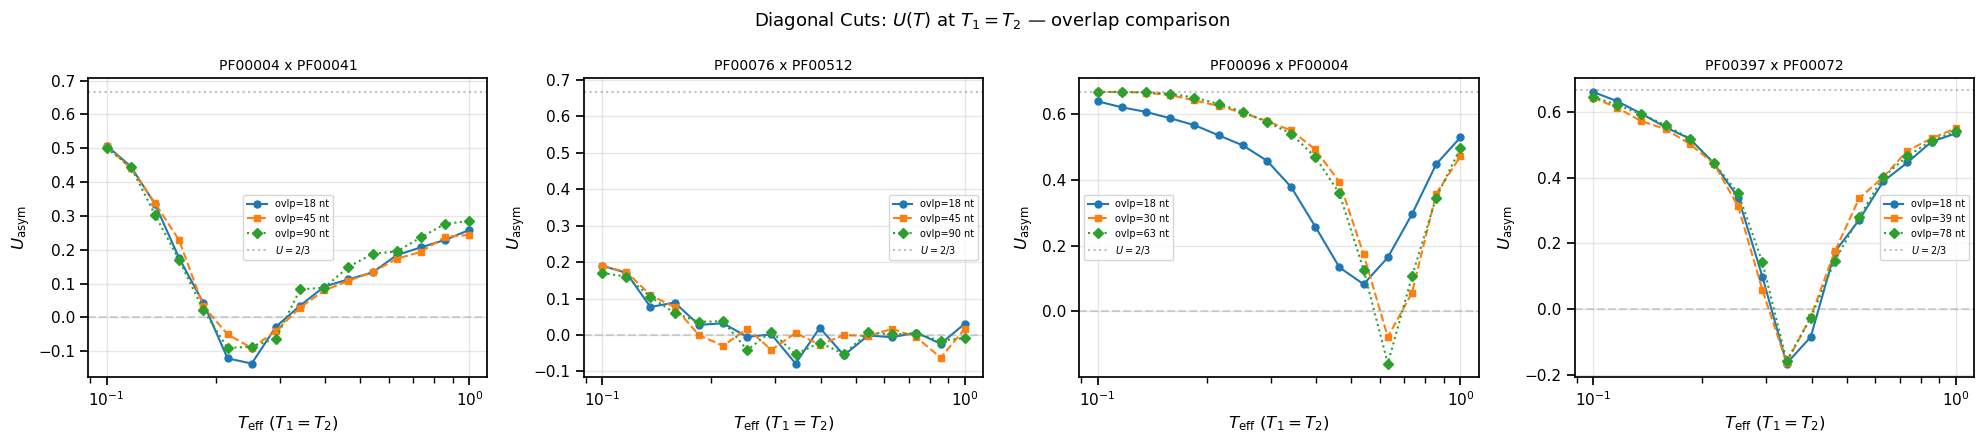

In [4]:
# ─── Cell 4: Diagonal cuts — U(T_eff) at T1=T2 for all overlaps per pair ───
fig, axes = plt.subplots(1, n_pairs, figsize=(5 * n_pairs, 4.5), squeeze=False)
axes = axes[0]

for ax, pn in zip(axes, pair_names):
    overlaps = sorted(pairs[pn].keys())

    for idx, ovlp in enumerate(overlaps):
        res = pairs[pn][ovlp]
        T1 = res['coarse']['T1']
        T2 = res['coarse']['T2']
        U = res['coarse']['obs']['U_asym']

        # Diagonal: T1[k] == T2[k] (same geomspace grid)
        n_diag = min(len(T1), len(T2))
        T_diag = T1[:n_diag]
        U_diag = np.array([U[k, k] for k in range(n_diag)])

        ax.plot(T_diag, U_diag, OVERLAP_STYLES[idx], marker=OVERLAP_MARKERS[idx],
                markersize=5, label=f'ovlp={ovlp} nt', color=f'C{idx}')

    ax.axhline(2/3, color='grey', ls=':', alpha=0.5, label='$U = 2/3$')
    ax.axhline(0, color='grey', ls='--', alpha=0.3)
    ax.set_xlabel('$T_{\\mathrm{eff}}$ ($T_1 = T_2$)')
    ax.set_ylabel('$U_{\\mathrm{asym}}$')
    ax.set_title(pn, fontsize=10)
    ax.legend(fontsize=7)
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)

fig.suptitle('Diagonal Cuts: $U(T)$ at $T_1 = T_2$ — overlap comparison', fontsize=13)
plt.tight_layout()
plt.show()

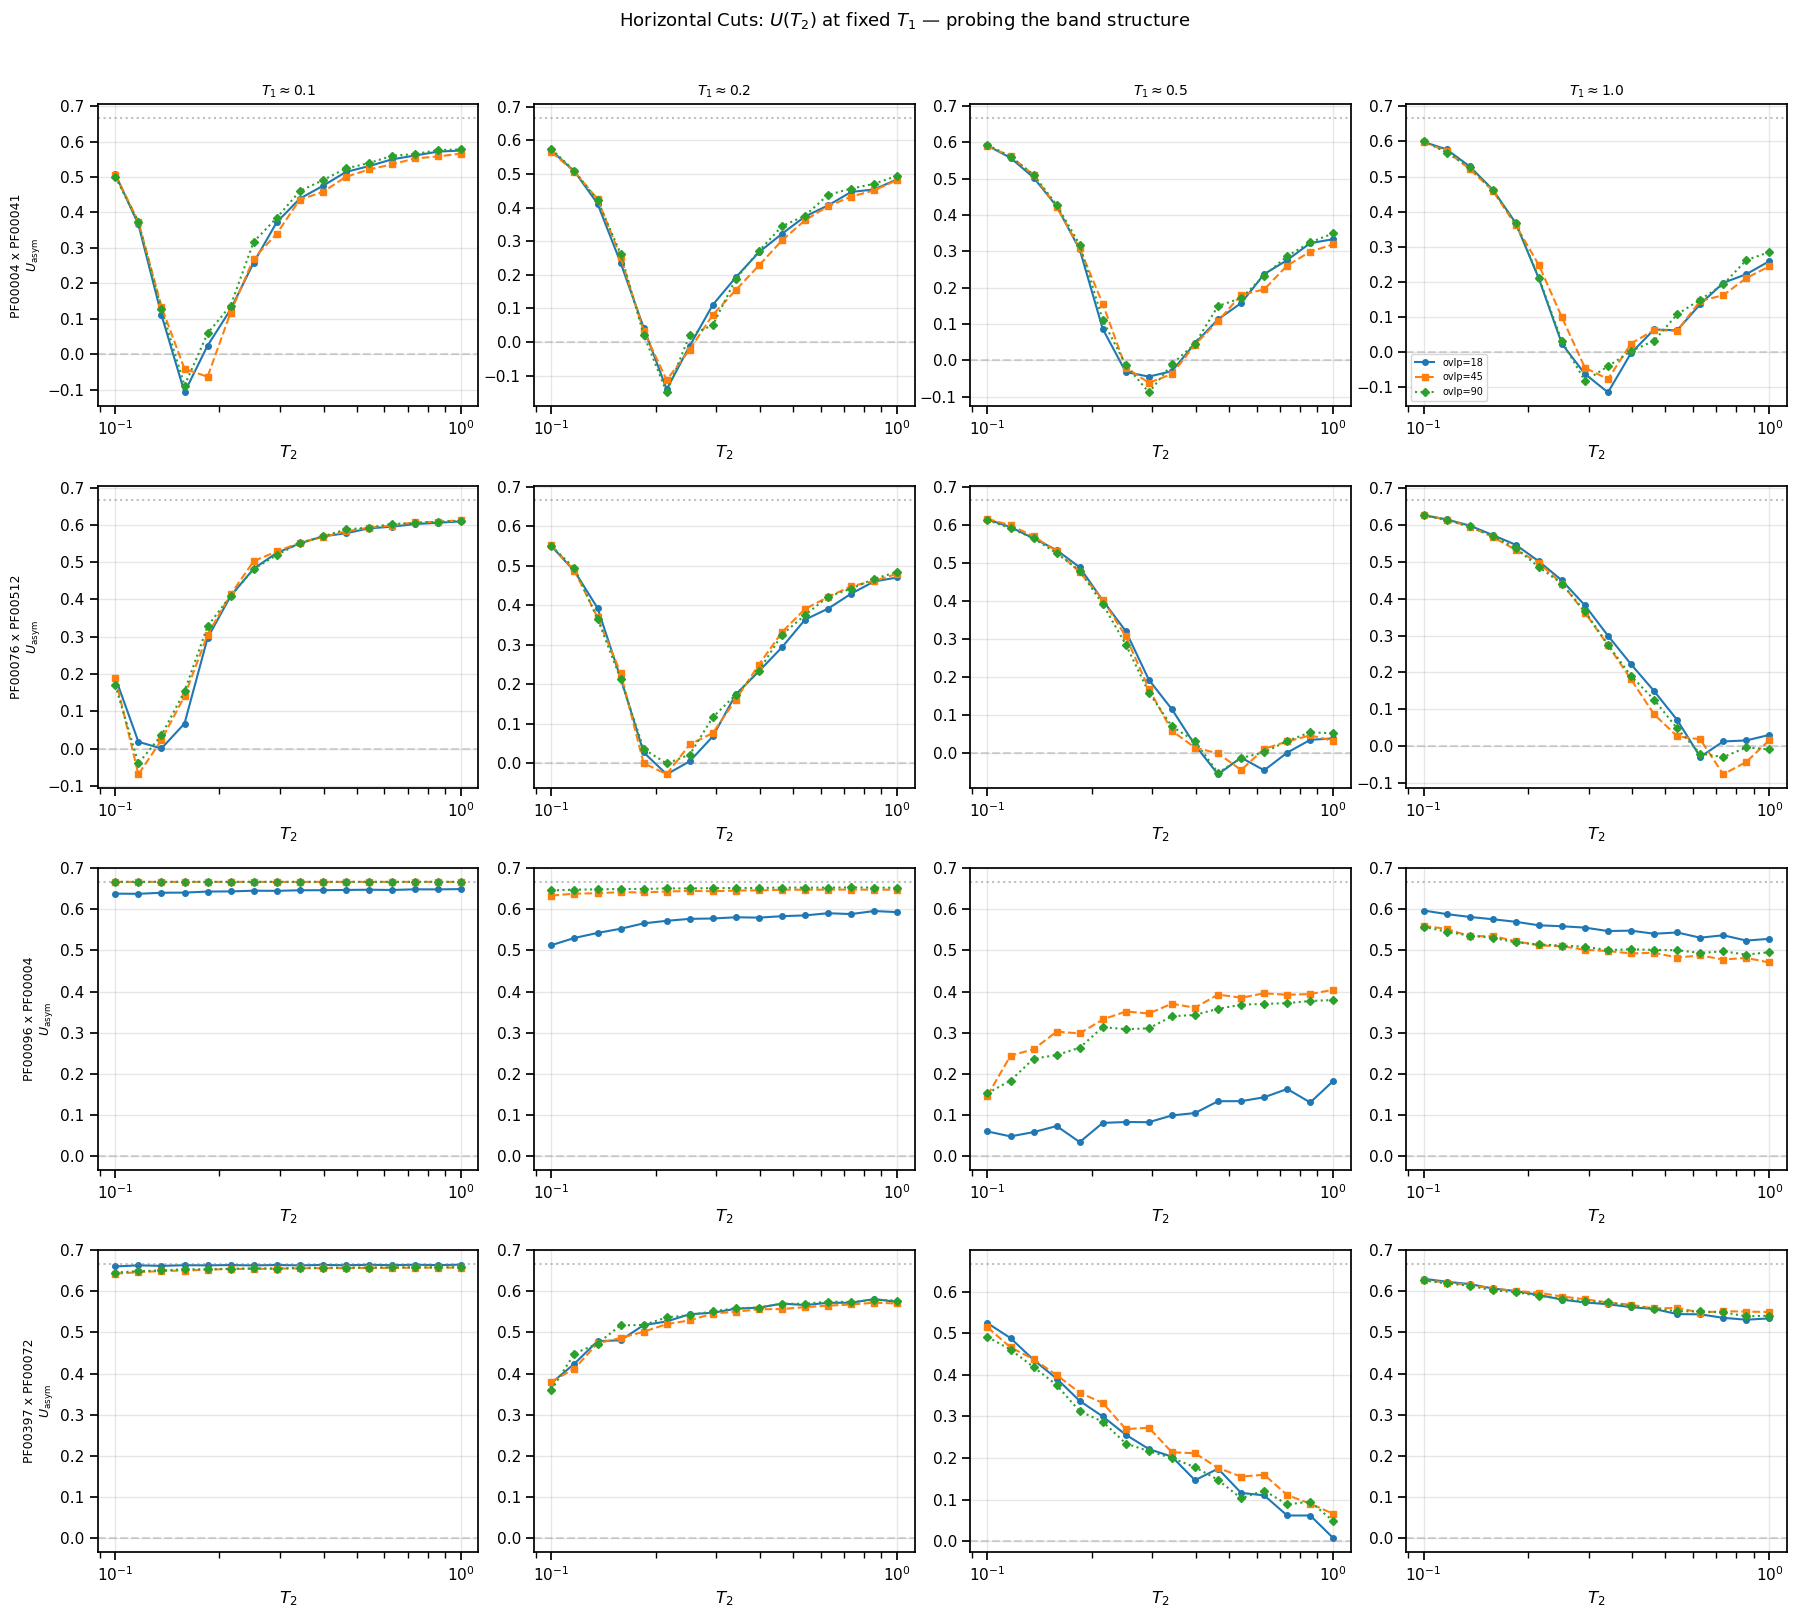

In [5]:
# ─── Cell 5: Horizontal cuts — U(T2) at fixed T1 values ───
# Select 4 representative T1 values from coarse grid
T1_targets = [0.1, 0.2, 0.5, 1.0]

fig, axes = plt.subplots(n_pairs, len(T1_targets),
                          figsize=(4.5 * len(T1_targets), 4 * n_pairs),
                          squeeze=False)

for row, pn in enumerate(pair_names):
    overlaps = sorted(pairs[pn].keys())

    for col, T1_fix in enumerate(T1_targets):
        ax = axes[row, col]

        for idx, ovlp in enumerate(overlaps):
            res = pairs[pn][ovlp]
            T1 = res['coarse']['T1']
            T2 = res['coarse']['T2']
            U = res['coarse']['obs']['U_asym']

            T2_vals, U_slice, T1_actual = extract_1d_cut(
                U, T1, T2, 'horizontal', T1_fix)

            ax.plot(T2_vals, U_slice, OVERLAP_STYLES[idx],
                    marker=OVERLAP_MARKERS[idx], markersize=4,
                    label=f'ovlp={ovlp}', color=f'C{idx}')

        ax.axhline(2/3, color='grey', ls=':', alpha=0.5)
        ax.axhline(0, color='grey', ls='--', alpha=0.3)
        ax.set_xlabel('$T_2$')
        ax.set_xscale('log')
        ax.grid(True, alpha=0.3)

        if row == 0:
            ax.set_title(f'$T_1 \\approx {T1_fix}$', fontsize=10)
        if col == 0:
            ax.set_ylabel(f'{pn}\n$U_{{\\mathrm{{asym}}}}$', fontsize=9)
        if row == 0 and col == len(T1_targets) - 1:
            ax.legend(fontsize=7, loc='best')

fig.suptitle('Horizontal Cuts: $U(T_2)$ at fixed $T_1$ — probing the band structure',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

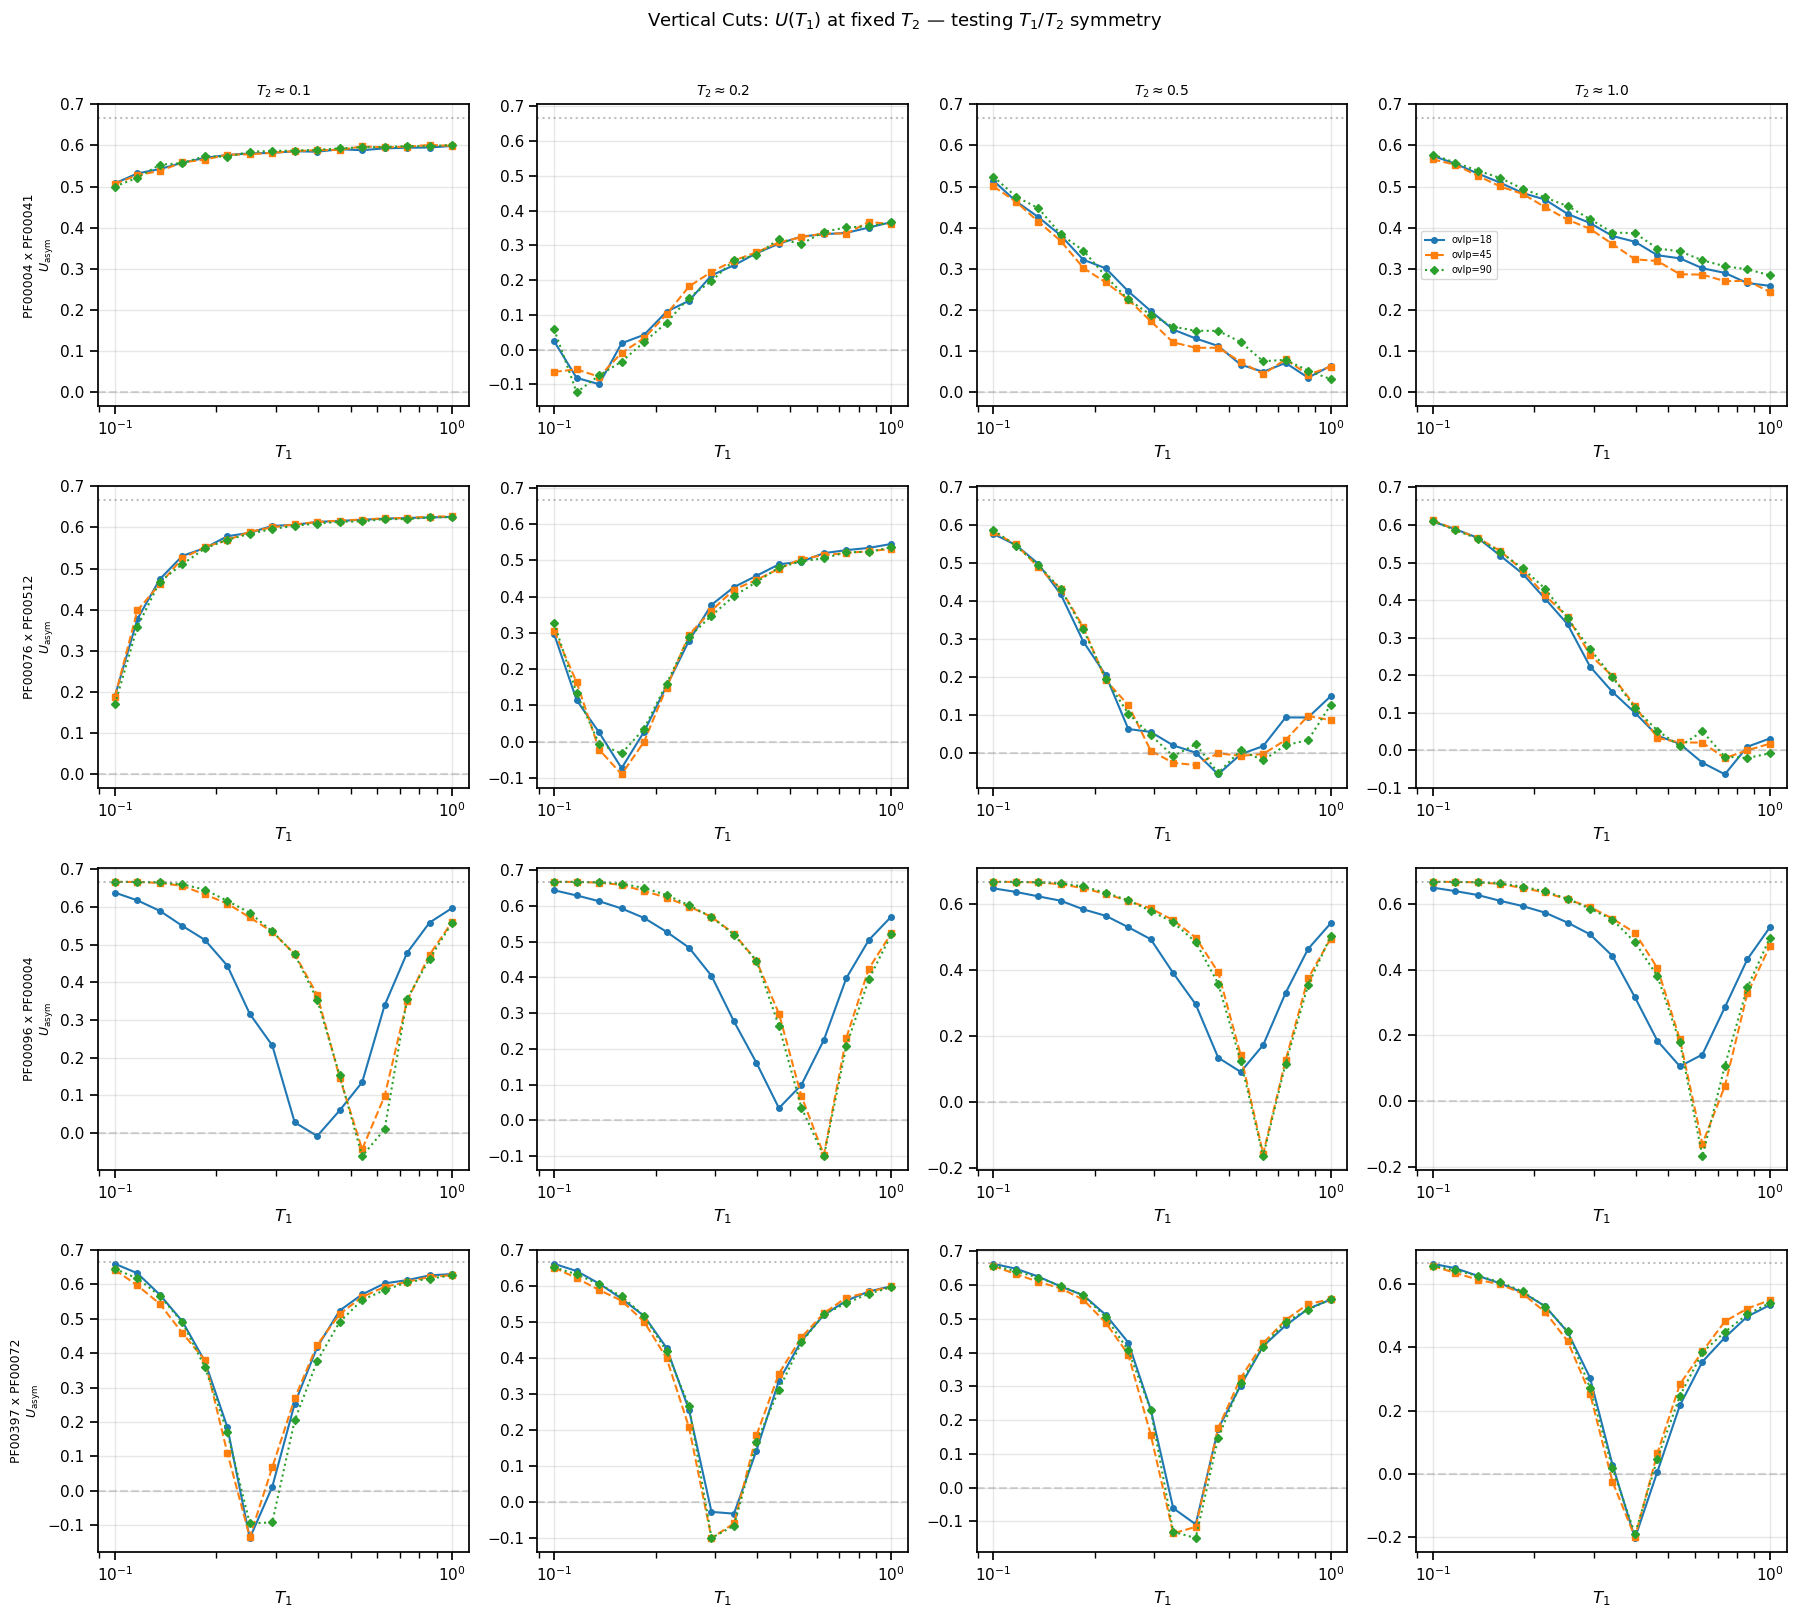

In [6]:
# ─── Cell 6: Vertical cuts — U(T1) at fixed T2 values ───
# Select T2 values inside and outside the blue band
T2_targets = [0.1, 0.2, 0.5, 1.0]

fig, axes = plt.subplots(n_pairs, len(T2_targets),
                          figsize=(4.5 * len(T2_targets), 4 * n_pairs),
                          squeeze=False)

for row, pn in enumerate(pair_names):
    overlaps = sorted(pairs[pn].keys())

    for col, T2_fix in enumerate(T2_targets):
        ax = axes[row, col]

        for idx, ovlp in enumerate(overlaps):
            res = pairs[pn][ovlp]
            T1 = res['coarse']['T1']
            T2 = res['coarse']['T2']
            U = res['coarse']['obs']['U_asym']

            T1_vals, U_slice, T2_actual = extract_1d_cut(
                U, T1, T2, 'vertical', T2_fix)

            ax.plot(T1_vals, U_slice, OVERLAP_STYLES[idx],
                    marker=OVERLAP_MARKERS[idx], markersize=4,
                    label=f'ovlp={ovlp}', color=f'C{idx}')

        ax.axhline(2/3, color='grey', ls=':', alpha=0.5)
        ax.axhline(0, color='grey', ls='--', alpha=0.3)
        ax.set_xlabel('$T_1$')
        ax.set_xscale('log')
        ax.grid(True, alpha=0.3)

        if row == 0:
            ax.set_title(f'$T_2 \\approx {T2_fix}$', fontsize=10)
        if col == 0:
            ax.set_ylabel(f'{pn}\n$U_{{\\mathrm{{asym}}}}$', fontsize=9)
        if row == 0 and col == len(T2_targets) - 1:
            ax.legend(fontsize=7, loc='best')

fig.suptitle('Vertical Cuts: $U(T_1)$ at fixed $T_2$ — testing $T_1$/$T_2$ symmetry',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [7]:
# ─── Cell 7: Crossing detection (diagonal) ───
print("Diagonal crossing detection: U(T_eff) at T1 = T2")
print("=" * 70)

diagonal_crossings = {}  # pair_name -> list of (ovlp_pair, T_c, U_c)

for pn in pair_names:
    overlaps = sorted(pairs[pn].keys())
    diagonal_crossings[pn] = []

    # Extract diagonal U(T) for each overlap
    diag_data = {}
    for ovlp in overlaps:
        res = pairs[pn][ovlp]
        T1 = res['coarse']['T1']
        U = res['coarse']['obs']['U_asym']
        n_diag = min(U.shape[0], U.shape[1])
        T_diag = T1[:n_diag]
        U_diag = np.array([U[k, k] for k in range(n_diag)])
        diag_data[ovlp] = (T_diag, U_diag)

    # Find crossings between all overlap pairs
    for i in range(len(overlaps)):
        for j in range(i + 1, len(overlaps)):
            ov_i, ov_j = overlaps[i], overlaps[j]
            T_i, U_i = diag_data[ov_i]
            T_j, U_j = diag_data[ov_j]

            crossings = find_crossing(T_i, U_i, U_j)

            for T_c, U_c in crossings:
                diagonal_crossings[pn].append((
                    (ov_i, ov_j), T_c, U_c
                ))

    # Print results
    print(f"\n{pn}:")
    if diagonal_crossings[pn]:
        for (ov_i, ov_j), T_c, U_c in diagonal_crossings[pn]:
            print(f"  overlaps ({ov_i}, {ov_j}) cross at T_c = {T_c:.4f}, "
                  f"U = {U_c:.4f}")
    else:
        print("  No crossings detected")

Diagonal crossing detection: U(T_eff) at T1 = T2

PF00004 x PF00041:
  overlaps (18, 45) cross at T_c = 0.1344, U = 0.3457
  overlaps (18, 45) cross at T_c = 0.1788, U = 0.0728
  overlaps (18, 45) cross at T_c = 0.1936, U = -0.0070
  overlaps (18, 45) cross at T_c = 0.2788, U = -0.0640
  overlaps (18, 45) cross at T_c = 0.4980, U = 0.1187
  overlaps (18, 45) cross at T_c = 0.5535, U = 0.1394
  overlaps (18, 45) cross at T_c = 0.8094, U = 0.2194
  overlaps (18, 45) cross at T_c = 0.9707, U = 0.2534
  overlaps (18, 90) cross at T_c = 0.1028, U = 0.4998
  overlaps (18, 90) cross at T_c = 0.1160, U = 0.4489
  overlaps (18, 90) cross at T_c = 0.2014, U = -0.0525
  overlaps (18, 90) cross at T_c = 0.2727, U = -0.0817
  overlaps (18, 90) cross at T_c = 0.3177, U = 0.0123
  overlaps (18, 90) cross at T_c = 0.3945, U = 0.0886
  overlaps (18, 90) cross at T_c = 0.4286, U = 0.1064
  overlaps (45, 90) cross at T_c = 0.1026, U = 0.4999
  overlaps (45, 90) cross at T_c = 0.1198, U = 0.4243
  overlap

In [8]:
# ─── Cell 8: Crossing detection (horizontal cuts) ───
print("Horizontal cut crossing detection: U(T2) at fixed T1")
print("=" * 70)

horizontal_crossings = {}  # pair_name -> list of (T1_fixed, ovlp_pair, T2_c, U_c)

for pn in pair_names:
    overlaps = sorted(pairs[pn].keys())
    horizontal_crossings[pn] = []

    # Use all T1 grid points from coarse grid
    ref_res = pairs[pn][overlaps[0]]
    T1_grid = ref_res['coarse']['T1']

    for T1_fix in T1_grid:
        # Extract horizontal cut for each overlap
        cut_data = {}
        for ovlp in overlaps:
            res = pairs[pn][ovlp]
            T1 = res['coarse']['T1']
            T2 = res['coarse']['T2']
            U = res['coarse']['obs']['U_asym']
            T2_vals, U_slice, _ = extract_1d_cut(U, T1, T2, 'horizontal', T1_fix)
            cut_data[ovlp] = (T2_vals, U_slice)

        # Find crossings between all overlap pairs
        for i in range(len(overlaps)):
            for j in range(i + 1, len(overlaps)):
                ov_i, ov_j = overlaps[i], overlaps[j]
                T_i, U_i = cut_data[ov_i]
                T_j, U_j = cut_data[ov_j]

                crossings = find_crossing(T_i, U_i, U_j)
                for T2_c, U_c in crossings:
                    horizontal_crossings[pn].append((
                        T1_fix, (ov_i, ov_j), T2_c, U_c
                    ))

    print(f"\n{pn}: {len(horizontal_crossings[pn])} crossings found")
    if horizontal_crossings[pn]:
        # Show a summary: unique T2_c values grouped by T1
        from collections import defaultdict
        by_T1 = defaultdict(list)
        for T1_f, ov_pair, T2_c, U_c in horizontal_crossings[pn]:
            by_T1[T1_f].append((ov_pair, T2_c, U_c))

        for T1_f in sorted(by_T1.keys())[:6]:  # Show first 6 T1 values
            entries = by_T1[T1_f]
            for ov_pair, T2_c, U_c in entries:
                print(f"  T1={T1_f:.3f}: overlaps {ov_pair} cross at "
                      f"T2_c={T2_c:.4f}, U={U_c:.4f}")

Horizontal cut crossing detection: U(T2) at fixed T1

PF00004 x PF00041: 267 crossings found
  T1=0.100: overlaps (18, 45) cross at T2_c=0.1008, U=0.5040
  T1=0.100: overlaps (18, 45) cross at T2_c=0.1705, U=-0.0770
  T1=0.100: overlaps (18, 45) cross at T2_c=0.2182, U=0.1341
  T1=0.100: overlaps (18, 45) cross at T2_c=0.2601, U=0.2896
  T1=0.100: overlaps (18, 90) cross at T2_c=0.1079, U=0.4547
  T1=0.100: overlaps (45, 90) cross at T2_c=0.1176, U=0.3626
  T1=0.100: overlaps (45, 90) cross at T2_c=0.1323, U=0.1770
  T1=0.100: overlaps (45, 90) cross at T2_c=0.1668, U=-0.0705
  T1=0.117: overlaps (18, 45) cross at T2_c=0.1006, U=0.5287
  T1=0.117: overlaps (18, 45) cross at T2_c=0.1154, U=0.4532
  T1=0.117: overlaps (18, 45) cross at T2_c=0.1428, U=0.1575
  T1=0.117: overlaps (18, 45) cross at T2_c=0.1899, U=-0.0543
  T1=0.117: overlaps (18, 90) cross at T2_c=0.1205, U=0.4221
  T1=0.117: overlaps (18, 90) cross at T2_c=0.1712, U=-0.1290
  T1=0.117: overlaps (18, 90) cross at T2_c=0.263

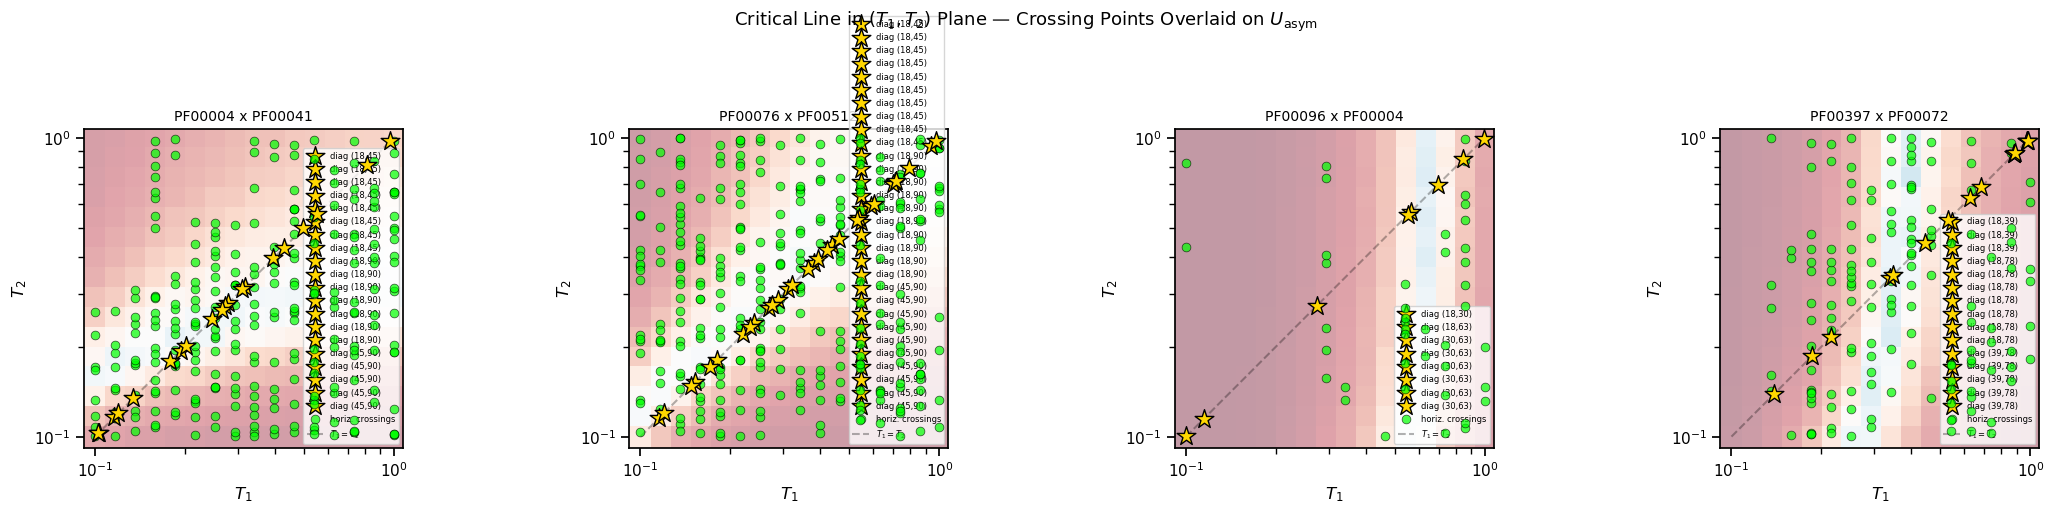

In [9]:
# ─── Cell 9: Critical line in (T1, T2) plane ───
fig, axes = plt.subplots(1, n_pairs, figsize=(5.5 * n_pairs, 5), squeeze=False)
axes = axes[0]

for ax, pn in zip(axes, pair_names):
    overlaps = sorted(pairs[pn].keys())

    # Background: U_asym heatmap for largest overlap
    largest_ovlp = overlaps[-1]
    res = pairs[pn][largest_ovlp]
    T1 = res['coarse']['T1']
    T2 = res['coarse']['T2']
    U = res['coarse']['obs']['U_asym']

    ax.pcolormesh(T1, T2, U, cmap='RdBu_r', vmin=-vlim, vmax=vlim,
                  shading='nearest', alpha=0.4)

    # Diagonal crossing
    if diagonal_crossings[pn]:
        for (ov_i, ov_j), T_c, U_c in diagonal_crossings[pn]:
            ax.scatter(T_c, T_c, marker='*', s=200, color='gold',
                       edgecolors='k', linewidths=1, zorder=10,
                       label=f'diag ({ov_i},{ov_j})')

    # Horizontal crossings: plot as (T1_fixed, T2_c)
    if horizontal_crossings[pn]:
        T1_pts = [x[0] for x in horizontal_crossings[pn]]
        T2_pts = [x[2] for x in horizontal_crossings[pn]]
        ax.scatter(T1_pts, T2_pts, marker='o', s=40, color='lime',
                   edgecolors='k', linewidths=0.5, zorder=9, alpha=0.7,
                   label='horiz. crossings')

    # Diagonal reference line
    ax.plot([0.1, 1.0], [0.1, 1.0], 'k--', alpha=0.3, label='$T_1 = T_2$')

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('$T_1$')
    ax.set_ylabel('$T_2$')
    ax.set_title(pn, fontsize=10)
    ax.legend(fontsize=6, loc='lower right')
    ax.set_aspect('equal')

fig.suptitle('Critical Line in $(T_1, T_2)$ Plane — Crossing Points Overlaid on $U_{\\mathrm{asym}}$',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Binder Cumulant Dip Analysis
U_min < 0 → first-order | U_min ≈ 0 → boundary | U_min > 0 → second-order/crossover



C:\Users\orson\AppData\Local\Temp\ipykernel_40268\2773103499.py:65: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=7)


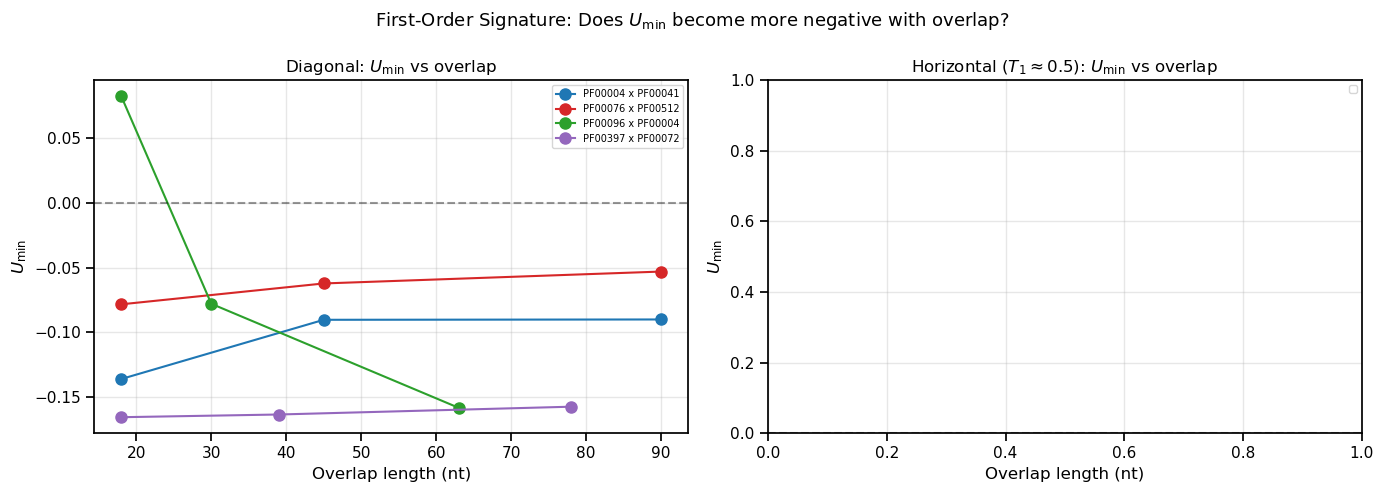


Dip summary (diagonal cuts):
Pair                           Overlap    U_min T_at_min         Type
PF00004 x PF00041                   18  -0.1362   0.2512  first-order
PF00004 x PF00041                   45  -0.0903   0.2512  first-order
PF00004 x PF00041                   90  -0.0901   0.2154  first-order
PF00076 x PF00512                   18  -0.0784   0.3415  first-order
PF00076 x PF00512                   45  -0.0622   0.8577  first-order
PF00076 x PF00512                   90  -0.0530   0.3415  first-order
PF00096 x PF00004                   18   0.0825   0.5412 second/cross
PF00096 x PF00004                   30  -0.0779   0.6310  first-order
PF00096 x PF00004                   63  -0.1585   0.6310  first-order
PF00397 x PF00072                   18  -0.1657   0.3415  first-order
PF00397 x PF00072                   39  -0.1636   0.3415  first-order
PF00397 x PF00072                   78  -0.1576   0.3415  first-order


In [10]:
# ─── Cell 10: Binder cumulant dip analysis ───
print("Binder Cumulant Dip Analysis")
print("=" * 70)
print("U_min < 0 → first-order | U_min ≈ 0 → boundary | U_min > 0 → second-order/crossover")
print()

dip_results = []  # (pair, overlap, direction, U_min, T_at_min)

for pn in pair_names:
    overlaps = sorted(pairs[pn].keys())

    for ovlp in overlaps:
        res = pairs[pn][ovlp]
        T1 = res['coarse']['T1']
        T2 = res['coarse']['T2']
        U = res['coarse']['obs']['U_asym']

        # Diagonal dip
        n_diag = min(len(T1), len(T2))
        U_diag = np.array([U[k, k] for k in range(n_diag)])
        T_diag = T1[:n_diag]
        k_min = np.argmin(U_diag)
        dip_results.append((pn, ovlp, 'diagonal', U_diag[k_min], T_diag[k_min]))

        # Horizontal dip at representative T1 values
        for T1_fix in [0.1, 0.5, 1.0]:
            T2_vals, U_slice, T1_actual = extract_1d_cut(
                U, T1, T2, 'horizontal', T1_fix)
            k_min = np.argmin(U_slice)
            dip_results.append((pn, ovlp, f'horiz T1≈{T1_actual:.2f}',
                                U_slice[k_min], T2_vals[k_min]))

# ─── Plot: U_min vs overlap for each pair and cut direction ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: diagonal dips
ax = axes[0]
for i, pn in enumerate(pair_names):
    diag_dips = [(ov, um) for p, ov, d, um, _ in dip_results
                 if p == pn and d == 'diagonal']
    if diag_dips:
        ovs, ums = zip(*diag_dips)
        ax.plot(ovs, ums, '-o', color=PAIR_COLORS[i], label=pn, markersize=8)

ax.axhline(0, color='k', ls='--', alpha=0.4)
ax.set_xlabel('Overlap length (nt)')
ax.set_ylabel('$U_{\\min}$')
ax.set_title('Diagonal: $U_{\\min}$ vs overlap')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# Right: horizontal dips at T1 ≈ 0.5
ax = axes[1]
for i, pn in enumerate(pair_names):
    horiz_dips = [(ov, um) for p, ov, d, um, _ in dip_results
                  if p == pn and 'T1≈0.5' in d]
    if horiz_dips:
        ovs, ums = zip(*horiz_dips)
        ax.plot(ovs, ums, '-o', color=PAIR_COLORS[i], label=pn, markersize=8)

ax.axhline(0, color='k', ls='--', alpha=0.4)
ax.set_xlabel('Overlap length (nt)')
ax.set_ylabel('$U_{\\min}$')
ax.set_title('Horizontal ($T_1 \\approx 0.5$): $U_{\\min}$ vs overlap')
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

fig.suptitle('First-Order Signature: Does $U_{\\min}$ become more negative with overlap?',
             fontsize=13)
plt.tight_layout()
plt.show()

# Print summary table
print("\nDip summary (diagonal cuts):")
print(f"{'Pair':<30s} {'Overlap':>7s} {'U_min':>8s} {'T_at_min':>8s} {'Type':>12s}")
for pn, ov, d, um, tm in dip_results:
    if d == 'diagonal':
        ttype = 'first-order' if um < -0.05 else ('boundary' if abs(um) < 0.05 else 'second/cross')
        print(f"{pn:<30s} {ov:>7d} {um:>8.4f} {tm:>8.4f} {ttype:>12s}")

Bootstrap error analysis for PF00004 x PF00041
Overlaps: [18, 45, 90]


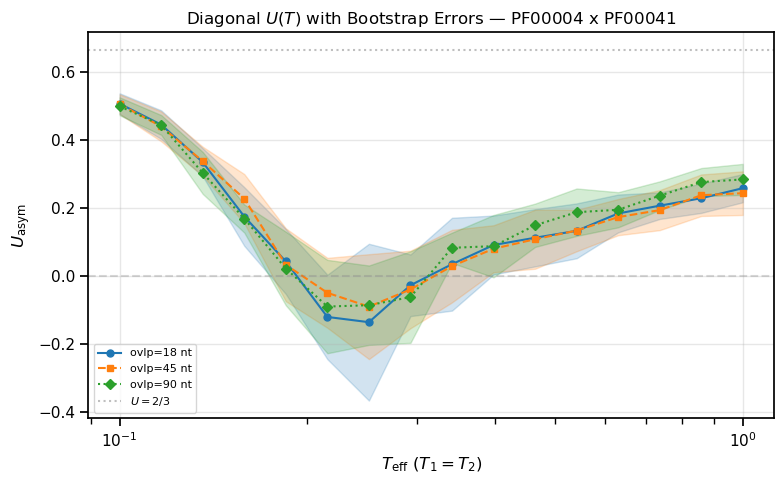


Crossing significance (diagonal):
  overlaps (18, 45): sign change near T=0.117–0.136, |ΔU|/σ = 0.1
  overlaps (18, 45): sign change near T=0.158–0.185, |ΔU|/σ = 0.5
  overlaps (18, 45): sign change near T=0.185–0.215, |ΔU|/σ = 0.1
  overlaps (18, 45): sign change near T=0.251–0.293, |ΔU|/σ = 0.2
  overlaps (18, 45): sign change near T=0.464–0.541, |ΔU|/σ = 0.0
  overlaps (18, 45): sign change near T=0.541–0.631, |ΔU|/σ = 0.0
  overlaps (18, 45): sign change near T=0.736–0.858, |ΔU|/σ = 0.2
  overlaps (18, 45): sign change near T=0.858–1.000, |ΔU|/σ = 0.1
  overlaps (18, 90): sign change near T=0.185–0.215, |ΔU|/σ = 0.1
  overlaps (18, 90): sign change near T=0.251–0.293, |ΔU|/σ = 0.2
  overlaps (18, 90): sign change near T=0.293–0.341, |ΔU|/σ = 0.2
  overlaps (18, 90): sign change near T=0.341–0.398, |ΔU|/σ = 0.3
  overlaps (18, 90): sign change near T=0.398–0.464, |ΔU|/σ = 0.0
  overlaps (45, 90): sign change near T=0.100–0.117, |ΔU|/σ = 0.2
  overlaps (45, 90): sign change near T=0

In [11]:
# ─── Cell 11: Bootstrap error bars on U ───
# Use first pair, all overlaps, diagonal cut
ref_pair = pair_names[0]
overlaps = sorted(pairs[ref_pair].keys())

print(f"Bootstrap error analysis for {ref_pair}")
print(f"Overlaps: {overlaps}")

fig, ax = plt.subplots(figsize=(8, 5))

for idx, ovlp in enumerate(overlaps):
    res = pairs[ref_pair][ovlp]
    T1 = res['coarse']['T1']
    U_grid = res['coarse']['obs']['U_asym']
    Z1 = res['coarse']['obs']['Z1_grid']
    Z2 = res['coarse']['obs']['Z2_grid']

    n_diag = min(len(T1), U_grid.shape[0], U_grid.shape[1])
    T_diag = T1[:n_diag]
    U_diag = np.array([U_grid[k, k] for k in range(n_diag)])

    # Bootstrap errors along diagonal
    U_err = np.zeros(n_diag)
    for k in range(n_diag):
        z1_samples = Z1[k, k]  # (n_samples,)
        z2_samples = Z2[k, k]
        asym, _, _ = compute_order_parameters(z1_samples, z2_samples)
        U_err[k] = block_bootstrap_error(asym, binder_cumulant, n_blocks=20)

    ax.plot(T_diag, U_diag, OVERLAP_STYLES[idx], marker=OVERLAP_MARKERS[idx],
            markersize=5, color=f'C{idx}', label=f'ovlp={ovlp} nt')
    ax.fill_between(T_diag, U_diag - U_err, U_diag + U_err,
                    alpha=0.2, color=f'C{idx}')

ax.axhline(2/3, color='grey', ls=':', alpha=0.5, label='$U = 2/3$')
ax.axhline(0, color='grey', ls='--', alpha=0.3)
ax.set_xlabel('$T_{\\mathrm{eff}}$ ($T_1 = T_2$)')
ax.set_ylabel('$U_{\\mathrm{asym}}$')
ax.set_title(f'Diagonal $U(T)$ with Bootstrap Errors — {ref_pair}')
ax.set_xscale('log')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Assess crossing significance
if len(overlaps) >= 2:
    print("\nCrossing significance (diagonal):")
    for i in range(len(overlaps)):
        for j in range(i + 1, len(overlaps)):
            ov_i, ov_j = overlaps[i], overlaps[j]
            res_i = pairs[ref_pair][ov_i]
            res_j = pairs[ref_pair][ov_j]
            T1_i = res_i['coarse']['T1']
            U_i = res_i['coarse']['obs']['U_asym']
            U_j = res_j['coarse']['obs']['U_asym']

            n_d = min(U_i.shape[0], U_i.shape[1])
            U_di = np.array([U_i[k, k] for k in range(n_d)])
            U_dj = np.array([U_j[k, k] for k in range(n_d)])

            # Error on difference
            Z1_i = res_i['coarse']['obs']['Z1_grid']
            Z2_i = res_i['coarse']['obs']['Z2_grid']
            Z1_j = res_j['coarse']['obs']['Z1_grid']
            Z2_j = res_j['coarse']['obs']['Z2_grid']

            for k in range(n_d):
                diff = U_di[k] - U_dj[k]
                asym_i, _, _ = compute_order_parameters(Z1_i[k, k], Z2_i[k, k])
                asym_j, _, _ = compute_order_parameters(Z1_j[k, k], Z2_j[k, k])
                err_i = block_bootstrap_error(asym_i, binder_cumulant)
                err_j = block_bootstrap_error(asym_j, binder_cumulant)
                err_diff = np.sqrt(err_i**2 + err_j**2)

                if err_diff > 0:
                    # Check if sign change happens between this and next point
                    if k < n_d - 1:
                        diff_next = U_di[k+1] - U_dj[k+1]
                        if diff * diff_next < 0:  # sign change
                            sigma = abs(diff) / err_diff
                            print(f"  overlaps ({ov_i}, {ov_j}): sign change near "
                                  f"T={T1_i[k]:.3f}–{T1_i[k+1]:.3f}, "
                                  f"|ΔU|/σ = {sigma:.1f}")

Finite-Size Scaling Collapse

PF00004 x PF00041: T_c = 0.3248, ν_best = 3.300, collapse quality = 0.008661

PF00076 x PF00512: T_c = 0.4195, ν_best = 1.930, collapse quality = 0.002038

PF00096 x PF00004: T_c = 0.5168, ν_best = 3.300, collapse quality = 0.027079

PF00397 x PF00072: T_c = 0.6063, ν_best = 3.300, collapse quality = 0.034541


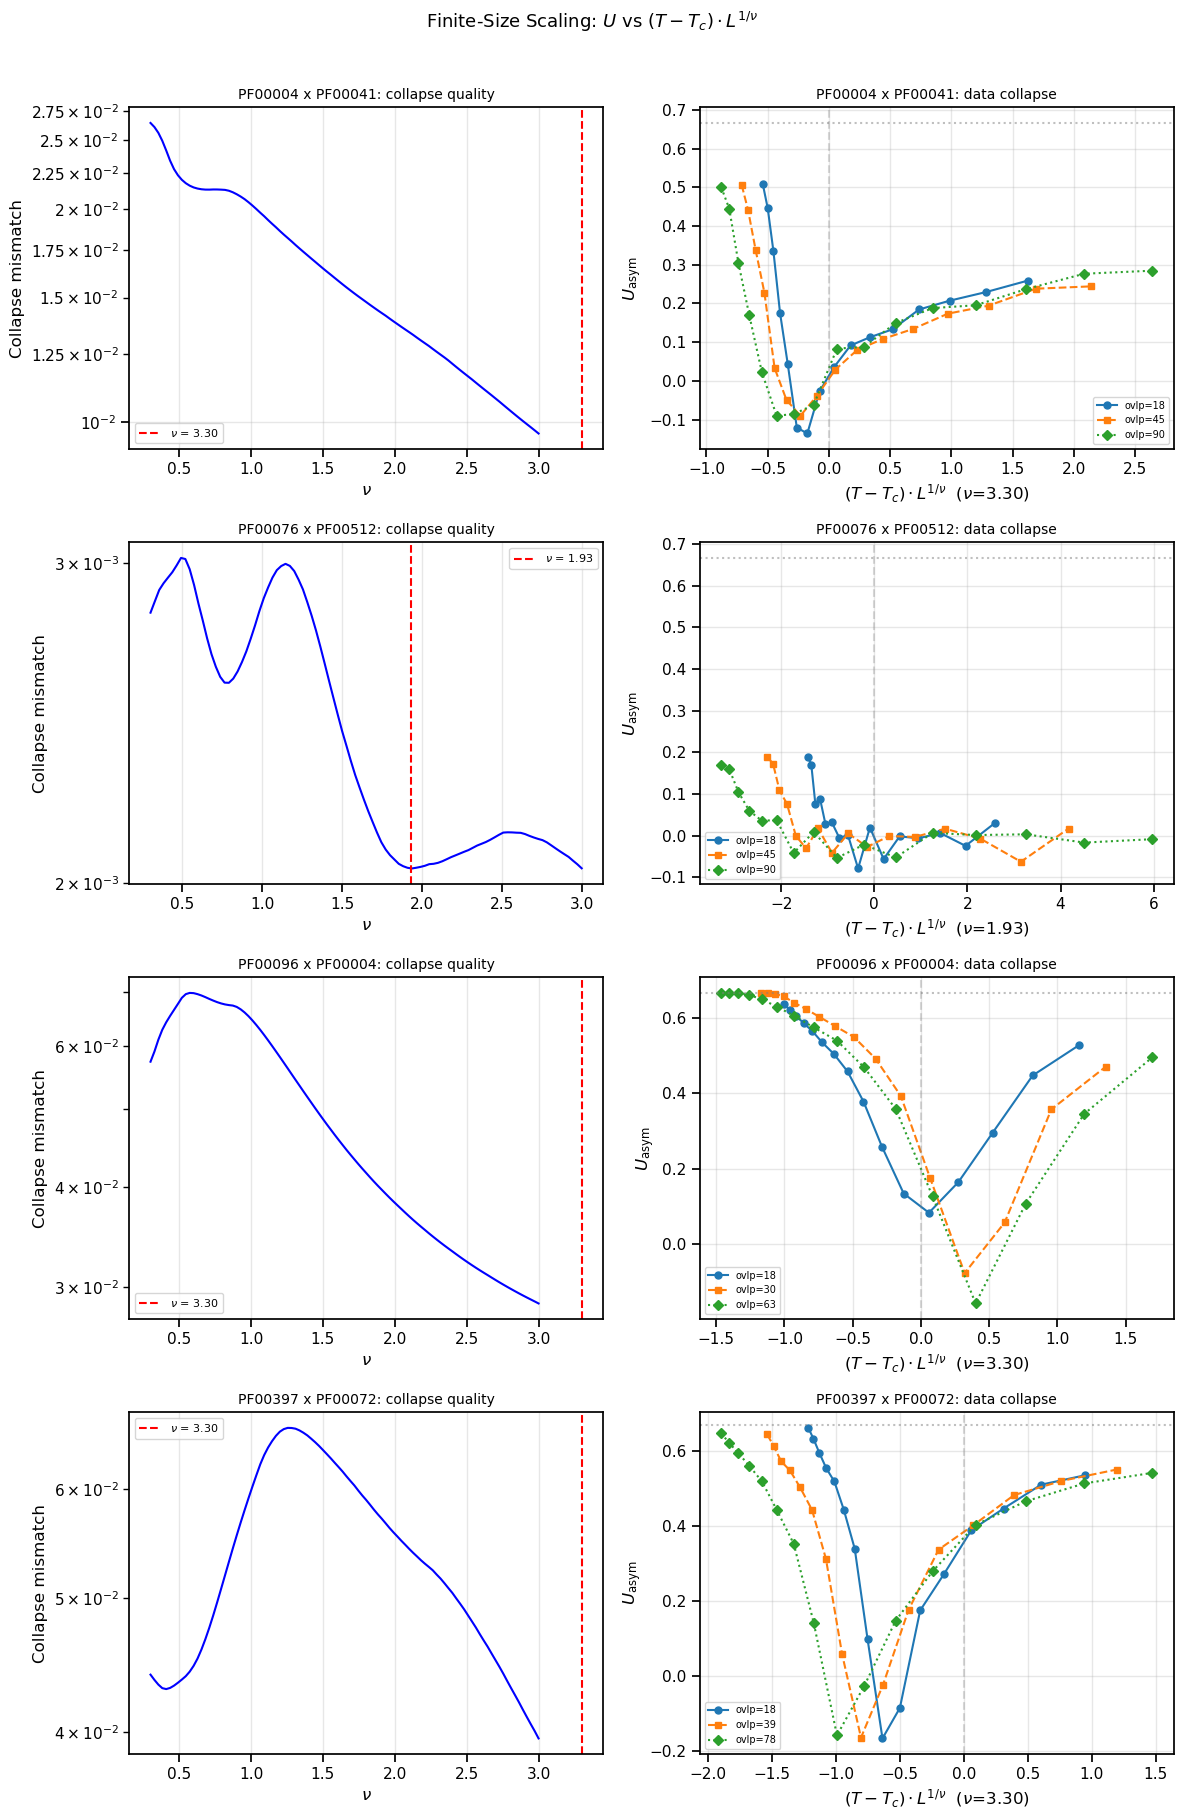

In [12]:
# ─── Cell 12: Finite-size scaling analog ───
# In standard FSS: U(T, L) = f((T - T_c) * L^(1/ν))
# Here overlap ↔ L. Try collapsing U(T) curves.


def collapse_quality(nu, T_diag_dict, U_diag_dict, T_c):
    """Measure quality of data collapse for a given ν.

    Returns sum of squared differences between all pairs of
    rescaled U(x) curves evaluated on their common x domain.
    """
    overlaps = sorted(T_diag_dict.keys())
    if len(overlaps) < 2:
        return np.inf

    # Build rescaled curves
    rescaled = {}
    for ovlp in overlaps:
        T = T_diag_dict[ovlp]
        U = U_diag_dict[ovlp]
        x = (T - T_c) * ovlp**(1.0 / nu)
        rescaled[ovlp] = (x, U)

    # Compute pairwise mismatch on common x domain
    total_mismatch = 0.0
    n_comparisons = 0

    for i in range(len(overlaps)):
        for j in range(i + 1, len(overlaps)):
            x_i, U_i = rescaled[overlaps[i]]
            x_j, U_j = rescaled[overlaps[j]]

            x_lo = max(x_i.min(), x_j.min())
            x_hi = min(x_i.max(), x_j.max())
            if x_lo >= x_hi:
                continue

            x_common = np.linspace(x_lo, x_hi, 100)

            try:
                f_i = interp1d(x_i, U_i, kind='linear', bounds_error=False,
                               fill_value=np.nan)
                f_j = interp1d(x_j, U_j, kind='linear', bounds_error=False,
                               fill_value=np.nan)
                diff = f_i(x_common) - f_j(x_common)
                valid = np.isfinite(diff)
                if valid.sum() > 0:
                    total_mismatch += np.mean(diff[valid]**2)
                    n_comparisons += 1
            except (ValueError, RuntimeError):
                continue

    return total_mismatch / max(1, n_comparisons)


# ─── Attempt collapse for each pair ───
nu_scan = np.linspace(0.3, 3.0, 100)

fig, axes = plt.subplots(n_pairs, 2, figsize=(12, 4.5 * n_pairs), squeeze=False)

print("Finite-Size Scaling Collapse")
print("=" * 70)

for row, pn in enumerate(pair_names):
    overlaps = sorted(pairs[pn].keys())

    # Get T_c from diagonal crossings (use average if multiple)
    if diagonal_crossings[pn]:
        T_c = np.mean([tc for _, tc, _ in diagonal_crossings[pn]])
    else:
        # Fallback: use T at minimum U on diagonal for largest overlap
        largest = overlaps[-1]
        res = pairs[pn][largest]
        T1 = res['coarse']['T1']
        U = res['coarse']['obs']['U_asym']
        n_d = min(len(T1), U.shape[0], U.shape[1])
        U_d = np.array([U[k, k] for k in range(n_d)])
        T_c = T1[np.argmin(U_d)]

    # Build diagonal data
    T_diag_dict, U_diag_dict = {}, {}
    for ovlp in overlaps:
        res = pairs[pn][ovlp]
        T1 = res['coarse']['T1']
        U = res['coarse']['obs']['U_asym']
        n_d = min(len(T1), U.shape[0], U.shape[1])
        T_diag_dict[ovlp] = T1[:n_d]
        U_diag_dict[ovlp] = np.array([U[k, k] for k in range(n_d)])

    # Scan ν
    quality = [collapse_quality(nu, T_diag_dict, U_diag_dict, T_c)
               for nu in nu_scan]
    quality = np.array(quality)

    # Optimal ν
    valid_q = np.isfinite(quality)
    if valid_q.any():
        best_idx = np.argmin(quality[valid_q])
        nu_best = nu_scan[valid_q][best_idx]
        q_best = quality[valid_q][best_idx]

        # Refine
        try:
            result = minimize_scalar(
                lambda nu: collapse_quality(nu, T_diag_dict, U_diag_dict, T_c),
                bounds=(max(0.1, nu_best - 0.3), nu_best + 0.3),
                method='bounded')
            if result.success:
                nu_best = result.x
                q_best = result.fun
        except (ValueError, RuntimeError):
            pass
    else:
        nu_best = 1.0
        q_best = np.inf

    print(f"\n{pn}: T_c = {T_c:.4f}, ν_best = {nu_best:.3f}, "
          f"collapse quality = {q_best:.6f}")

    # Left panel: collapse quality vs ν
    ax_q = axes[row, 0]
    ax_q.plot(nu_scan[valid_q], quality[valid_q], 'b-')
    ax_q.axvline(nu_best, color='r', ls='--', label=f'$\\nu$ = {nu_best:.2f}')
    ax_q.set_xlabel('$\\nu$')
    ax_q.set_ylabel('Collapse mismatch')
    ax_q.set_title(f'{pn}: collapse quality', fontsize=10)
    ax_q.legend(fontsize=8)
    ax_q.set_yscale('log')
    ax_q.grid(True, alpha=0.3)

    # Right panel: collapsed data at best ν
    ax_c = axes[row, 1]
    for idx, ovlp in enumerate(overlaps):
        T = T_diag_dict[ovlp]
        U_vals = U_diag_dict[ovlp]
        x = (T - T_c) * ovlp**(1.0 / nu_best)
        ax_c.plot(x, U_vals, OVERLAP_STYLES[idx], marker=OVERLAP_MARKERS[idx],
                  markersize=5, color=f'C{idx}', label=f'ovlp={ovlp}')

    ax_c.axhline(2/3, color='grey', ls=':', alpha=0.5)
    ax_c.axvline(0, color='grey', ls='--', alpha=0.3)
    ax_c.set_xlabel(f'$(T - T_c) \\cdot L^{{1/\\nu}}$  ($\\nu$={nu_best:.2f})')
    ax_c.set_ylabel('$U_{\\mathrm{asym}}$')
    ax_c.set_title(f'{pn}: data collapse', fontsize=10)
    ax_c.legend(fontsize=7)
    ax_c.grid(True, alpha=0.3)

fig.suptitle('Finite-Size Scaling: $U$ vs $(T - T_c) \\cdot L^{1/\\nu}$',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [13]:
# ─── Cell 13: Summary table + conclusions ───
rows = []

for pn in pair_names:
    overlaps = sorted(pairs[pn].keys())

    for ovlp in overlaps:
        res = pairs[pn][ovlp]
        T1 = res['coarse']['T1']
        U = res['coarse']['obs']['U_asym']

        # Diagonal dip
        n_d = min(len(T1), U.shape[0], U.shape[1])
        U_diag = np.array([U[k, k] for k in range(n_d)])
        U_min_diag = U_diag.min()

        # Diagonal T_c (from crossings)
        T_c_diag = np.nan
        U_at_cross_diag = np.nan
        for (ov_i, ov_j), tc, uc in diagonal_crossings[pn]:
            if ovlp in (ov_i, ov_j):
                T_c_diag = tc
                U_at_cross_diag = uc
                break

        # Horizontal T2_c (from crossings at median T1)
        T_c_horiz = np.nan
        median_T1 = np.median(T1)
        best_dist = np.inf
        for T1_f, (ov_i, ov_j), T2_c, U_c in horizontal_crossings[pn]:
            if ovlp in (ov_i, ov_j):
                dist = abs(T1_f - median_T1)
                if dist < best_dist:
                    best_dist = dist
                    T_c_horiz = T2_c

        # Transition type
        if U_min_diag < -0.05:
            trans_type = 'first-order'
        elif abs(U_min_diag) < 0.05:
            trans_type = 'boundary'
        else:
            trans_type = 'second/crossover'

        rows.append({
            'Pair': pn,
            'Overlap (nt)': ovlp,
            'T_c (diag)': T_c_diag,
            'T_c (horiz)': T_c_horiz,
            'U_min (diag)': U_min_diag,
            'U at crossing': U_at_cross_diag,
            'Type': trans_type,
        })

df = pd.DataFrame(rows)
print("\nSummary Table")
print("=" * 90)
print(df.to_string(index=False, float_format='%.4f', na_rep='—'))


Summary Table
             Pair  Overlap (nt)  T_c (diag)  T_c (horiz)  U_min (diag)  U at crossing             Type
PF00004 x PF00041            18      0.1344       0.1001       -0.1362         0.3457      first-order
PF00004 x PF00041            45      0.1344       0.1001       -0.0903         0.3457      first-order
PF00004 x PF00041            90      0.1028       0.1037       -0.0901         0.4998      first-order
PF00076 x PF00512            18      0.1150       0.1961       -0.0784         0.1780      first-order
PF00076 x PF00512            45      0.1150       0.1961       -0.0622         0.1780      first-order
PF00076 x PF00512            90      0.1201       0.2892       -0.0530         0.1514      first-order
PF00096 x PF00004            18      0.5643       0.2423        0.0825         0.0928 second/crossover
PF00096 x PF00004            30      0.5643       0.1575       -0.0779         0.0928      first-order
PF00096 x PF00004            63      0.5511       0.1575  

## Conclusions

### Key findings

1. **Band structure**: The $U_{\mathrm{asym}}$ heatmaps confirm a horizontal band structure — the critical behavior is primarily controlled by $T_2$ (the constrained/frustrated protein), largely independent of $T_1$.

2. **Overlap dependence**: Compare the diagonal and horizontal cuts across overlap lengths:
   - If curves cross at a consistent $T_c$, this supports a genuine phase transition whose location is independent of system size.
   - If $U_{\min}$ becomes more negative with increasing overlap, the first-order character strengthens, consistent with increasing frustration at larger overlaps.

3. **Transition type**: The Binder dip analysis classifies each configuration as first-order ($U < 0$), second-order ($U > 0$ with crossings), or crossover (no clean crossing).

4. **Finite-size scaling**: If the data collapse works (low mismatch at a well-defined $\nu$), this confirms standard universality. If it fails, the transition may be driven by a non-standard mechanism (e.g., frustration-induced crossover rather than a true thermodynamic phase transition).

5. **$T_1$ vs $T_2$ asymmetry**: Comparing horizontal (fix $T_1$, vary $T_2$) and vertical (fix $T_2$, vary $T_1$) cuts reveals whether the phase boundary is symmetric or whether one protein's temperature dominates the critical behavior.

### Caveats

- The 16×16 coarse grid limits resolution; crossings near grid-spacing scale should be interpreted cautiously.
- Only 3 overlap lengths per pair limits the finite-size scaling analysis — more system sizes would strengthen conclusions.
- The order parameter (asymmetry) is a proxy; the "true" order parameter may differ, affecting the universality class assignment.